# Step 02: SQL Agent Execution Accuracy 평가

> Base 모델(qwen3:8b) vs Fine-tuned 모델(qwen3-hr)의 **Execution Accuracy** 측정

## 평가 목표

이 노트북은 **Execution Accuracy**를 측정합니다:
- SQL 문법이 달라도 **실행 결과가 같으면 정답**으로 인정
- 현업 표준(defog-ai/sql-eval)의 `compare_query_results()` 패턴 적용

## 노트북 구조

```
Part 1: 환경 설정 및 개념 복습
Part 2: 핵심 평가 함수 (현업 표준 패턴)
Part 3: 모델 평가 실행
Part 4: 결과 분석 및 시각화
Part 5: 결과 저장
```

---

## Part 1: 환경 설정 및 개념 복습

### 💡 Execution Accuracy란?

**현업 표준 (defog-ai/sql-eval)**:
- `exact_match`: SQL 텍스트가 같은가? → 너무 엄격하여 사용 안 함
- `is_correct`: **실행 결과가 같은가?** → 이것이 **Execution Accuracy**!

```python
# defog-ai/sql-eval 예시
exact_match, is_correct = compare_query_results(
    query_gold="SELECT author.name FROM author...",
    query_gen="SELECT a.name FROM author a...",  # SQL은 다르지만
    db_name="academic"
)
# exact_match=False (SQL 텍스트가 다름)
# is_correct=True (실행 결과가 같음) ← Execution Accuracy!
```

### RAG vs SQL 평가 비교

| 항목 | RAG | SQL |
|------|-----|-----|
| **평가 대상** | 텍스트 답변 | 쿼리 실행 결과 |
| **표준 도구** | RAGAS | defog-ai/sql-eval |
| **평가 방식** | LLM-as-Judge | DB 실행 결과 비교 |
| **왜?** | 텍스트는 다양한 표현 | SQL은 결과로 판단 |

In [1]:
# 1-1. 환경 설정
import os
import sys
import json
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import List, Dict, Any, Optional
import warnings
warnings.filterwarnings('ignore')

# 프로젝트 루트 설정
PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project Root: {PROJECT_ROOT}")

Project Root: C:\workspace\enterprise-hr-agent


In [2]:
# 1-2. 환경 변수 및 모델 설정
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

# 모델 설정
BASE_MODEL = "qwen3:8b"           # 베이스 모델
FINETUNED_MODEL = "qwen3-hr"      # 파인튜닝 모델
PROVIDER = "ollama"
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")

print(f"Base Model: {BASE_MODEL}")
print(f"Fine-tuned Model: {FINETUNED_MODEL}")
print(f"Ollama URL: {OLLAMA_BASE_URL}")

Base Model: qwen3:8b
Fine-tuned Model: qwen3-hr
Ollama URL: http://localhost:11434


In [3]:
# 1-3. 테스트 데이터 로드
DATA_DIR = PROJECT_ROOT / "data" / "finetuning"

with open(DATA_DIR / "sql_test.json", "r", encoding="utf-8") as f:
    test_cases = json.load(f)

print(f"SQL 테스트 케이스: {len(test_cases)}개")

# 테스트 데이터 미리보기
import pandas as pd
test_df = pd.DataFrame(test_cases)
display(test_df[['id', 'question', 'category']])

SQL 테스트 케이스: 10개


,id,question,category
0,1,영업팀에서 가장 높은 급여를 받는 사람은?,aggregation_join
1,2,과장 직급의 평균 급여는 얼마야?,aggregation_filter
2,3,2024년 1월 3일에 지각한 직원 명단,join_filter
3,4,현재 휴직 중인 직원은 누구야?,simple_filter
4,5,평가 점수가 4.5 이상인 우수 직원 목록,join_filter_sort
5,6,보너스 총액이 가장 큰 부서는?,aggregation_group
6,7,2020년 이후에 입사한 직원은 몇 명이야?,count_filter
7,8,인사팀 대리의 급여 정보 알려줘,multi_filter_join
8,9,가장 오래 근무한 직원은 누구야?,sort_limit
9,10,부서별 평균 평가 점수를 알려줘,aggregation_group_join


---

## Part 2: 핵심 평가 함수 (현업 표준 패턴)

### defog-ai/sql-eval의 `normalize_table()` 패턴

결과 비교를 위한 정규화 단계:
1. **중복 제거**: 동일한 행 제거
2. **컬럼 정렬**: 알파벳 순으로 정렬
3. **행 정렬**: ORDER BY가 없는 경우 순서 무시
4. **타입 통일**: 문자열로 변환하여 비교

In [4]:
# 2-1. 결과 데이터 구조 (dataclass 사용)

@dataclass
class SQLEvalResult:
    """
    단일 테스트 케이스 결과
    
    현업 표준 (defog-ai/sql-eval)의 결과 구조를 참고하여 설계:
    - exact_match → 우리는 사용 안 함 (너무 엄격)
    - is_correct → result_match (Execution Accuracy)
    """
    id: int
    question: str
    category: str
    expected_sql: str
    generated_sql: str
    execution_success: bool      # SQL 실행 성공 여부
    result_match: bool           # 결과 일치 (Execution Accuracy)
    expected_result: Optional[List[Dict]] = None
    generated_result: Optional[List[Dict]] = None
    error: Optional[str] = None

print("SQLEvalResult 클래스 정의 완료")

SQLEvalResult 클래스 정의 완료


In [5]:
# 2-2. 결과 비교 함수 (defog-ai/sql-eval의 normalize_table 패턴)

def normalize_and_compare(result1: List[Dict], result2: List[Dict]) -> bool:
    """
    두 SQL 실행 결과 비교 (Execution Accuracy 핵심 로직)
    
    현업 표준 패턴 (defog-ai/sql-eval normalize_table):
    1. 중복 제거
    2. 값만 비교 (컬럼 이름 무시)
    3. 행 정렬 (ORDER BY 없는 경우)
    4. 비교
    
    Args:
        result1: 첫 번째 SQL 실행 결과 (List[Dict])
        result2: 두 번째 SQL 실행 결과 (List[Dict])
        
    Returns:
        bool: 결과가 같으면 True, 다르면 False
    """
    # None 체크
    if result1 is None or result2 is None:
        return False
    
    # 행 개수 체크
    if len(result1) != len(result2):
        return False
    
    # 빈 결과는 같음
    if len(result1) == 0:
        return True
    
    def normalize(results: List[Dict]) -> List[tuple]:
        """
        결과를 정렬 가능한 형태로 정규화
        
        Steps:
        1. 각 행의 값만 추출 (컬럼 이름 무시)
        2. 값을 문자열로 통일 (타입 차이 무시)
        3. 값 정렬 후 튜플로 변환 (hashable하게)
        4. 전체 행 정렬 (순서 무시)
        """
        normalized = []
        for row in results:
            # Step 1-3: 값만 추출하고 정렬 (컬럼 이름 무시)
            values = tuple(sorted(str(v) if v is not None else "NULL" for v in row.values()))
            normalized.append(values)
        # Step 4: 행 정렬 (순서 무시)
        return sorted(normalized)
    
    return normalize(result1) == normalize(result2)

# 테스트
test1 = [{"name": "홍길동", "salary": 5000000}]
test2 = [{"salary": 5000000, "name": "홍길동"}]  # 컬럼 순서 다름
print(f"컬럼 순서 다른 경우: {normalize_and_compare(test1, test2)}")

test3 = [{"name": "홍길동"}, {"name": "김철수"}]
test4 = [{"name": "김철수"}, {"name": "홍길동"}]  # 행 순서 다름
print(f"행 순서 다른 경우: {normalize_and_compare(test3, test4)}")

# 새 테스트: 컬럼 이름만 다른 경우 (값은 동일)
test5 = [{"name": "홍길동"}]
test6 = [{"e.name": "홍길동"}]  # alias로 컬럼명 다름
print(f"컬럼 이름만 다른 경우: {normalize_and_compare(test5, test6)}")

컬럼 순서 다른 경우: True
행 순서 다른 경우: True
컬럼 이름만 다른 경우: True


In [6]:
# 2-3. 단일 케이스 평가 함수 (최적화: SQL만 생성, 답변 생성 스킵)

def evaluate_single_case(
    agent,
    db,
    case: Dict
) -> SQLEvalResult:
    """
    단일 테스트 케이스 평가 (최적화 버전)
    
    평가 단계:
    1. LLM으로 SQL 생성 (답변 생성 스킵 - 속도 2배 향상)
    2. 생성된 SQL 실행
    3. 정답 SQL 실행
    4. 결과 비교 (Execution Accuracy)
    
    Args:
        agent: SQLAgent 인스턴스
        db: DatabaseConnection 인스턴스
        case: 테스트 케이스 딕셔너리
        
    Returns:
        SQLEvalResult: 평가 결과
    """
    # Step 1: SQL만 생성 (agent.query() 대신 워크플로우 직접 호출)
    # _generate_answer 호출을 스킵하여 속도 2배 향상
    schema = db.get_table_schema()
    
    state = {
        "question": case["question"],
        "schema": schema,
        "sql": "",
        "error": None,
        "results": None,
        "attempt": 0,
        "max_attempts": agent.max_attempts,
    }
    
    # LangGraph 워크플로우 실행 (SQL 생성 + 실행만)
    final = agent.app.invoke(state)
    generated_sql = final["sql"]
    
    # Step 2: 실행 결과 확인
    gen_result = final["results"]
    gen_error = final["error"]
    execution_success = gen_error is None and gen_result is not None
    
    # Step 3: 정답 SQL 실행
    exp_result, exp_error = db.execute_query(case["expected_sql"])
    
    # Step 4: Execution Accuracy 판정
    result_match = False
    if execution_success and exp_error is None:
        result_match = normalize_and_compare(gen_result, exp_result)
    
    return SQLEvalResult(
        id=case["id"],
        question=case["question"],
        category=case["category"],
        expected_sql=case["expected_sql"],
        generated_sql=generated_sql,
        execution_success=execution_success,
        result_match=result_match,
        expected_result=exp_result,
        generated_result=gen_result,
        error=gen_error
    )

print("evaluate_single_case 함수 정의 완료 (최적화 버전: 답변 생성 스킵)")

evaluate_single_case 함수 정의 완료 (최적화 버전: 답변 생성 스킵)


---

## Part 3: 모델 평가 실행

### 평가 메트릭 설명

| 메트릭 | 설명 |
|--------|------|
| **Execution Rate** | SQL이 에러 없이 실행된 비율 |
| **Execution Accuracy** | 실행 결과가 정답과 일치한 비율 (핵심!) |

In [7]:
# 3-1. 전체 평가 함수

def evaluate_model(
    model: str,
    test_cases: List[Dict],
    db
) -> Dict[str, Any]:
    """
    모델 전체 평가
    
    메트릭:
    - execution_rate: SQL 실행 성공률
    - execution_accuracy: 결과 일치율 (핵심!)
    
    Args:
        model: 모델 이름 (예: "qwen3:8b")
        test_cases: 테스트 케이스 리스트
        db: DatabaseConnection 인스턴스
        
    Returns:
        Dict with model, metrics, results
    """
    from core.agents.sql_agent import SQLAgent
    
    print(f"\n{'=' * 50}")
    print(f"모델 평가: {model}")
    print(f"{'=' * 50}")
    
    # Agent 초기화
    agent = SQLAgent(
        db=db,
        model=model,
        provider=PROVIDER,
        base_url=OLLAMA_BASE_URL,
        max_attempts=3
    )
    
    results = []
    for case in test_cases:
        print(f"  [{case['id']}/{len(test_cases)}] {case['question'][:40]}...")
        result = evaluate_single_case(agent, db, case)
        
        # 진행 상황 표시
        exec_status = "✓" if result.execution_success else "✗"
        match_status = "✓" if result.result_match else "✗"
        print(f"       실행: {exec_status} | 결과일치: {match_status}")
        
        results.append(result)
    
    # 메트릭 계산
    total = len(results)
    exec_success = sum(1 for r in results if r.execution_success)
    result_match = sum(1 for r in results if r.result_match)
    
    metrics = {
        "execution_rate": round(exec_success / total * 100, 1),
        "execution_accuracy": round(result_match / total * 100, 1),
        "execution_success_count": exec_success,
        "result_match_count": result_match,
        "total": total
    }
    
    print(f"\n📊 결과: 실행률 {metrics['execution_rate']}%, Execution Accuracy {metrics['execution_accuracy']}%")
    
    return {
        "model": model,
        "metrics": metrics,
        "results": [asdict(r) for r in results]
    }

print("evaluate_model 함수 정의 완료")

evaluate_model 함수 정의 완료


In [8]:
# 3-2. 데이터베이스 연결
from core.database.connection import DatabaseConnection

DATABASE_URL = os.getenv("DATABASE_URL")
db = DatabaseConnection(DATABASE_URL)

# 연결 테스트
print(f"DB 연결 성공: {DATABASE_URL.split('@')[1] if '@' in DATABASE_URL else 'Connected'}")

DB 연결 성공: localhost:3306/enterprise_hr_db


In [9]:
# 3-3. Base 모델 평가
print("🔵 Base 모델 평가 시작")
base_eval = evaluate_model(BASE_MODEL, test_cases, db)

🔵 Base 모델 평가 시작

모델 평가: qwen3:8b
  [1/10] 영업팀에서 가장 높은 급여를 받는 사람은?...
       실행: ✓ | 결과일치: ✓
  [2/10] 과장 직급의 평균 급여는 얼마야?...
       실행: ✓ | 결과일치: ✓
  [3/10] 2024년 1월 3일에 지각한 직원 명단...
       실행: ✓ | 결과일치: ✓
  [4/10] 현재 휴직 중인 직원은 누구야?...
       실행: ✓ | 결과일치: ✓
  [5/10] 평가 점수가 4.5 이상인 우수 직원 목록...
       실행: ✓ | 결과일치: ✗
  [6/10] 보너스 총액이 가장 큰 부서는?...
       실행: ✓ | 결과일치: ✗
  [7/10] 2020년 이후에 입사한 직원은 몇 명이야?...
       실행: ✓ | 결과일치: ✓
  [8/10] 인사팀 대리의 급여 정보 알려줘...
       실행: ✓ | 결과일치: ✗
  [9/10] 가장 오래 근무한 직원은 누구야?...
       실행: ✓ | 결과일치: ✗
  [10/10] 부서별 평균 평가 점수를 알려줘...
       실행: ✓ | 결과일치: ✓

📊 결과: 실행률 100.0%, Execution Accuracy 60.0%


In [10]:
# 3-4. Fine-tuned 모델 평가
print("🟢 Fine-tuned 모델 평가 시작")
ft_eval = evaluate_model(FINETUNED_MODEL, test_cases, db)

🟢 Fine-tuned 모델 평가 시작

모델 평가: qwen3-hr
  [1/10] 영업팀에서 가장 높은 급여를 받는 사람은?...
       실행: ✓ | 결과일치: ✗
  [2/10] 과장 직급의 평균 급여는 얼마야?...
       실행: ✓ | 결과일치: ✓
  [3/10] 2024년 1월 3일에 지각한 직원 명단...
       실행: ✓ | 결과일치: ✓
  [4/10] 현재 휴직 중인 직원은 누구야?...
       실행: ✓ | 결과일치: ✓
  [5/10] 평가 점수가 4.5 이상인 우수 직원 목록...
       실행: ✓ | 결과일치: ✓
  [6/10] 보너스 총액이 가장 큰 부서는?...
       실행: ✓ | 결과일치: ✗
  [7/10] 2020년 이후에 입사한 직원은 몇 명이야?...
       실행: ✓ | 결과일치: ✓
  [8/10] 인사팀 대리의 급여 정보 알려줘...
       실행: ✓ | 결과일치: ✗
  [9/10] 가장 오래 근무한 직원은 누구야?...
       실행: ✓ | 결과일치: ✗
  [10/10] 부서별 평균 평가 점수를 알려줘...
       실행: ✓ | 결과일치: ✓

📊 결과: 실행률 100.0%, Execution Accuracy 60.0%


---

## Part 4: 결과 분석 및 시각화

### 분석 항목
1. **비교 테이블**: Base vs Fine-tuned 메트릭 비교
2. **카테고리별 분석**: 쿼리 유형별 성능
3. **실패 케이스 분석**: 디버깅용

In [11]:
# 4-1. 비교 테이블
import pandas as pd

comparison_df = pd.DataFrame({
    "Metric": ["Execution Rate", "Execution Accuracy"],
    f"Base ({BASE_MODEL})": [
        f"{base_eval['metrics']['execution_rate']}%",
        f"{base_eval['metrics']['execution_accuracy']}%"
    ],
    f"Fine-tuned ({FINETUNED_MODEL})": [
        f"{ft_eval['metrics']['execution_rate']}%",
        f"{ft_eval['metrics']['execution_accuracy']}%"
    ],
    "Δ (차이)": [
        f"{ft_eval['metrics']['execution_rate'] - base_eval['metrics']['execution_rate']:+.1f}%",
        f"{ft_eval['metrics']['execution_accuracy'] - base_eval['metrics']['execution_accuracy']:+.1f}%"
    ]
})

print("\n" + "=" * 60)
print("📊 EXECUTION ACCURACY 비교")
print("=" * 60)
display(comparison_df)


📊 EXECUTION ACCURACY 비교


,Metric,Base (qwen3:8b),Fine-tuned (qwen3-hr),Δ (차이)
0,Execution Rate,100.0%,100.0%,+0.0%
1,Execution Accuracy,60.0%,60.0%,+0.0%


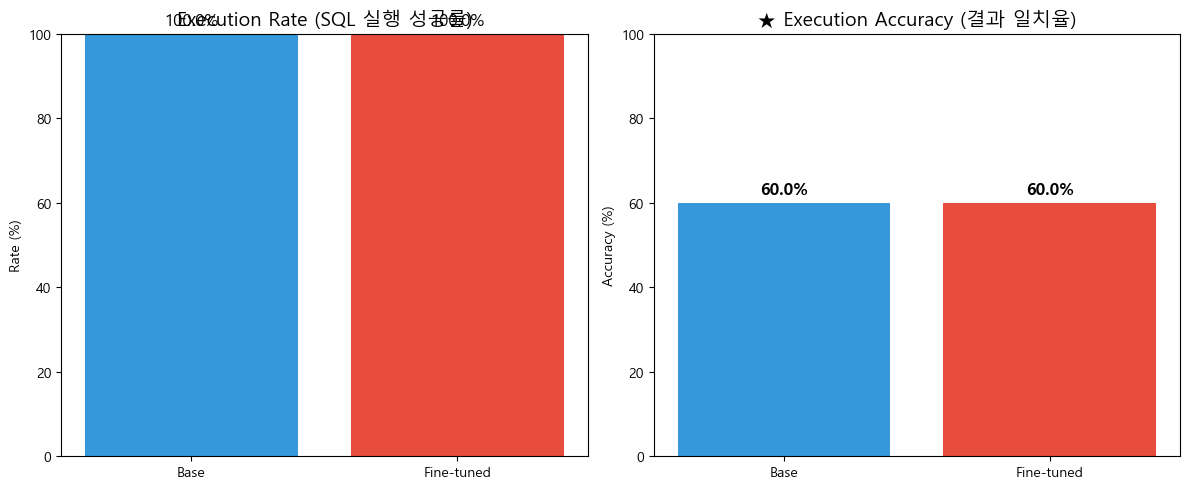

In [12]:
# 4-2. 시각화
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 색상
COLORS = {'base': '#3498db', 'finetuned': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['Base', 'Fine-tuned']
colors = [COLORS['base'], COLORS['finetuned']]

# 1. Execution Rate
exec_rates = [
    base_eval['metrics']['execution_rate'],
    ft_eval['metrics']['execution_rate']
]
bars1 = axes[0].bar(models, exec_rates, color=colors)
axes[0].set_ylabel('Rate (%)')
axes[0].set_title('Execution Rate (SQL 실행 성공률)', fontsize=14)
axes[0].set_ylim(0, 100)
for bar, val in zip(bars1, exec_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                 f'{val:.1f}%', ha='center', fontsize=12)

# 2. Execution Accuracy (핵심)
exec_acc = [
    base_eval['metrics']['execution_accuracy'],
    ft_eval['metrics']['execution_accuracy']
]
bars2 = axes[1].bar(models, exec_acc, color=colors)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('★ Execution Accuracy (결과 일치율)', fontsize=14)
axes[1].set_ylim(0, 100)
for bar, val in zip(bars2, exec_acc):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
# 4-3. 카테고리별 분석

def analyze_by_category(results: List[Dict], model_name: str) -> pd.DataFrame:
    """
    카테고리별 Execution Accuracy 분석
    """
    df = pd.DataFrame(results)
    analysis = df.groupby('category').agg({
        'execution_success': ['sum', 'count'],
        'result_match': 'sum'
    })
    analysis.columns = ['실행성공', '총개수', '결과일치']
    analysis['Execution Accuracy'] = (analysis['결과일치'] / analysis['총개수'] * 100).round(1).astype(str) + '%'
    return analysis[['총개수', '결과일치', 'Execution Accuracy']]

print(f"\n📊 카테고리별 Execution Accuracy")
print(f"\n[{BASE_MODEL}]")
display(analyze_by_category(base_eval['results'], BASE_MODEL))

print(f"\n[{FINETUNED_MODEL}]")
display(analyze_by_category(ft_eval['results'], FINETUNED_MODEL))


📊 카테고리별 Execution Accuracy

[qwen3:8b]


,총개수,결과일치,Execution Accuracy
category,,,
aggregation_filter,1,1,100.0%
aggregation_group,1,0,0.0%
aggregation_group_join,1,1,100.0%
aggregation_join,1,1,100.0%
count_filter,1,1,100.0%
join_filter,1,1,100.0%
join_filter_sort,1,0,0.0%
multi_filter_join,1,0,0.0%
simple_filter,1,1,100.0%



[qwen3-hr]


,총개수,결과일치,Execution Accuracy
category,,,
aggregation_filter,1,1,100.0%
aggregation_group,1,0,0.0%
aggregation_group_join,1,1,100.0%
aggregation_join,1,0,0.0%
count_filter,1,1,100.0%
join_filter,1,1,100.0%
join_filter_sort,1,1,100.0%
multi_filter_join,1,0,0.0%
simple_filter,1,1,100.0%


In [14]:
# 4-4. 실패 케이스 분석 (디버깅용)

def show_failures(results: List[Dict], model_name: str):
    """
    결과가 일치하지 않은 케이스 표시
    """
    failures = [r for r in results if not r['result_match']]
    
    if not failures:
        print(f"✅ {model_name}: 모든 케이스 성공!")
        return
    
    print(f"\n❌ {model_name}: {len(failures)}개 실패")
    print("-" * 60)
    
    for f in failures:
        print(f"[{f['id']}] {f['question']}")
        print(f"  카테고리: {f['category']}")
        print(f"  실행성공: {'✓' if f['execution_success'] else '✗'}")
        if f['generated_sql']:
            print(f"  생성 SQL: {f['generated_sql']}")
        if f['error']:
            print(f"  에러: {f['error'][:60]}")
        print()

print("=" * 60)
print("FAILURE ANALYSIS")
print("=" * 60)

show_failures(base_eval['results'], BASE_MODEL)
show_failures(ft_eval['results'], FINETUNED_MODEL)

FAILURE ANALYSIS

❌ qwen3:8b: 4개 실패
------------------------------------------------------------
[5] 평가 점수가 4.5 이상인 우수 직원 목록
  카테고리: join_filter_sort
  실행성공: ✓
  생성 SQL: SELECT employees.name, evaluations.score
FROM employees
JOIN evaluations ON employees.emp_id = evaluations.emp_id
WHERE evaluations.score >= 4.5;

[6] 보너스 총액이 가장 큰 부서는?
  카테고리: aggregation_group
  실행성공: ✓
  생성 SQL: SELECT departments.name, SUM(salaries.bonus) AS total_bonus
FROM salaries
JOIN employees ON salaries.emp_id = employees.emp_id
JOIN departments ON employees.dept_id = departments.dept_id
GROUP BY departments.name
ORDER BY total_bonus DESC
LIMIT 1;

[8] 인사팀 대리의 급여 정보 알려줘
  카테고리: multi_filter_join
  실행성공: ✓
  생성 SQL: SELECT salaries.base_salary, salaries.bonus, salaries.payment_date 
FROM employees 
JOIN salaries ON employees.emp_id = salaries.emp_id 
WHERE employees.dept_id = 3 AND employees.position = '대리';

[9] 가장 오래 근무한 직원은 누구야?
  카테고리: sort_limit
  실행성공: ✓
  생성 SQL: SELECT * FROM employees ORDER BY join_d

---

## Part 5: 결과 저장

평가 결과를 JSON 파일로 저장합니다.

In [15]:
# 5-1. 결과 저장

evaluation_results = {
    "timestamp": datetime.now().isoformat(),
    "config": {
        "base_model": BASE_MODEL,
        "finetuned_model": FINETUNED_MODEL,
        "provider": PROVIDER,
        "test_cases_count": len(test_cases)
    },
    "base": base_eval,
    "finetuned": ft_eval,
    "comparison": {
        "execution_rate_improvement": (
            ft_eval['metrics']['execution_rate'] - 
            base_eval['metrics']['execution_rate']
        ),
        "execution_accuracy_improvement": (
            ft_eval['metrics']['execution_accuracy'] - 
            base_eval['metrics']['execution_accuracy']
        )
    }
}

# JSON 저장 (expected_result, generated_result는 너무 커서 제외)
def clean_results(results: List[Dict]) -> List[Dict]:
    """저장용으로 결과 정리 (큰 필드 제외)"""
    cleaned = []
    for r in results:
        cleaned.append({
            "id": r["id"],
            "question": r["question"],
            "category": r["category"],
            "expected_sql": r["expected_sql"],
            "generated_sql": r["generated_sql"],
            "execution_success": r["execution_success"],
            "result_match": r["result_match"],
            "error": r["error"]
        })
    return cleaned

evaluation_results["base"]["results"] = clean_results(base_eval["results"])
evaluation_results["finetuned"]["results"] = clean_results(ft_eval["results"])

output_path = PROJECT_ROOT / "data" / "finetuning" / "sql_evaluation_results.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(evaluation_results, f, ensure_ascii=False, indent=2, default=str)

print(f"✅ 결과 저장됨: {output_path}")

✅ 결과 저장됨: C:\workspace\enterprise-hr-agent\data\finetuning\sql_evaluation_results.json


In [16]:
# 5-2. 최종 요약

print("\n" + "=" * 70)
print("📋 FINAL SUMMARY")
print("=" * 70)

improvement = evaluation_results["comparison"]["execution_accuracy_improvement"]

print(f"\n┌{'─'*68}┐")
print(f"│ {'Metric':<25} │ {'Base':>15} │ {'Fine-tuned':>15} │")
print(f"├{'─'*68}┤")
print(f"│ {'Execution Rate':<25} │ {base_eval['metrics']['execution_rate']:>14.1f}% │ {ft_eval['metrics']['execution_rate']:>14.1f}% │")
print(f"│ {'★ Execution Accuracy':<25} │ {base_eval['metrics']['execution_accuracy']:>14.1f}% │ {ft_eval['metrics']['execution_accuracy']:>14.1f}% │")
print(f"└{'─'*68}┘")

print(f"\n📈 Execution Accuracy 개선: {improvement:+.1f}%")

if improvement > 10:
    print("\n✅ 파인튜닝 효과가 유의미합니다. 프로덕션 적용을 고려하세요.")
elif improvement > 0:
    print("\n△ 소폭 개선되었습니다. 추가 학습 데이터를 검토하세요.")
else:
    print("\n⚠️ 개선이 없습니다. 학습 데이터와 방법을 재검토하세요.")


📋 FINAL SUMMARY

┌────────────────────────────────────────────────────────────────────┐
│ Metric                    │            Base │      Fine-tuned │
├────────────────────────────────────────────────────────────────────┤
│ Execution Rate            │          100.0% │          100.0% │
│ ★ Execution Accuracy      │           60.0% │           60.0% │
└────────────────────────────────────────────────────────────────────┘

📈 Execution Accuracy 개선: +0.0%

⚠️ 개선이 없습니다. 학습 데이터와 방법을 재검토하세요.


---

## 평가 완료

이 노트북에서 수행한 내용:

1. ✅ **Execution Accuracy 개념**: defog-ai/sql-eval 표준 패턴 적용
2. ✅ **결과 정규화**: `normalize_and_compare()` 함수로 순서/타입 무관 비교
3. ✅ **Base vs Fine-tuned 비교**: 메트릭 테이블 및 시각화
4. ✅ **카테고리별 분석**: 쿼리 유형별 성능 확인
5. ✅ **결과 저장**: `sql_evaluation_results.json`

### 다음 단계
- 실패 케이스를 학습 데이터에 추가
- 프롬프트 엔지니어링으로 SQL 생성 품질 개선
- RAG Agent 평가 (step_03)